In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [2]:
import os
import pandas as pd
import anndata as ad
import scanpy as sc

from metab_processing.metab_travlr_config import DATA_DIR

In [3]:
ADATA_PATH = DATA_DIR + '/Alexi_UC_Full_Data/adata.h5ad'

In [4]:
adata = sc.read_h5ad(ADATA_PATH)

In [5]:
adata

AnnData object with n_obs × n_vars = 260611 × 4736
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'orientation_cores', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'leiden', 'leiden_res_1_5', 'leiden_res_1_3', 'leiden_res_1_4', 'leiden_res_1_6', 'leiden_res_1_2', '25_06_11_ICI_5K_Compartments', '24_11_12_ICI_5K_Fine_annotations', '25_06_11_ICI_5K_Coarse_annotations', '240927_Condition', '25_06_11_Patient_ID_HS'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_c

In [6]:
# Check how many cells belong to each Patient ID
print("Cell counts per Patient ID:")
print(adata.obs['25_06_11_Patient_ID_HS'].value_counts())

# Check how many cells belong to each Condition
print("\nCell counts per Condition:")
print(adata.obs['240927_Condition'].value_counts())

Cell counts per Patient ID:
25_06_11_Patient_ID_HS
13114_HS1_HC     36350
13473_HS4_UC     36118
13674_HS9_ICI    34444
13318_HS6_UC     33767
13557_HS3_HC     32641
13732_HS5_UC     27076
13117_HS2_HC     26109
9553_HS8_ICI     17466
12362_HS7_ICI    16513
unassigned         127
Name: count, dtype: int64

Cell counts per Condition:
240927_Condition
UC            96961
HC            95100
ICI           68423
unassigned      127
Name: count, dtype: int64


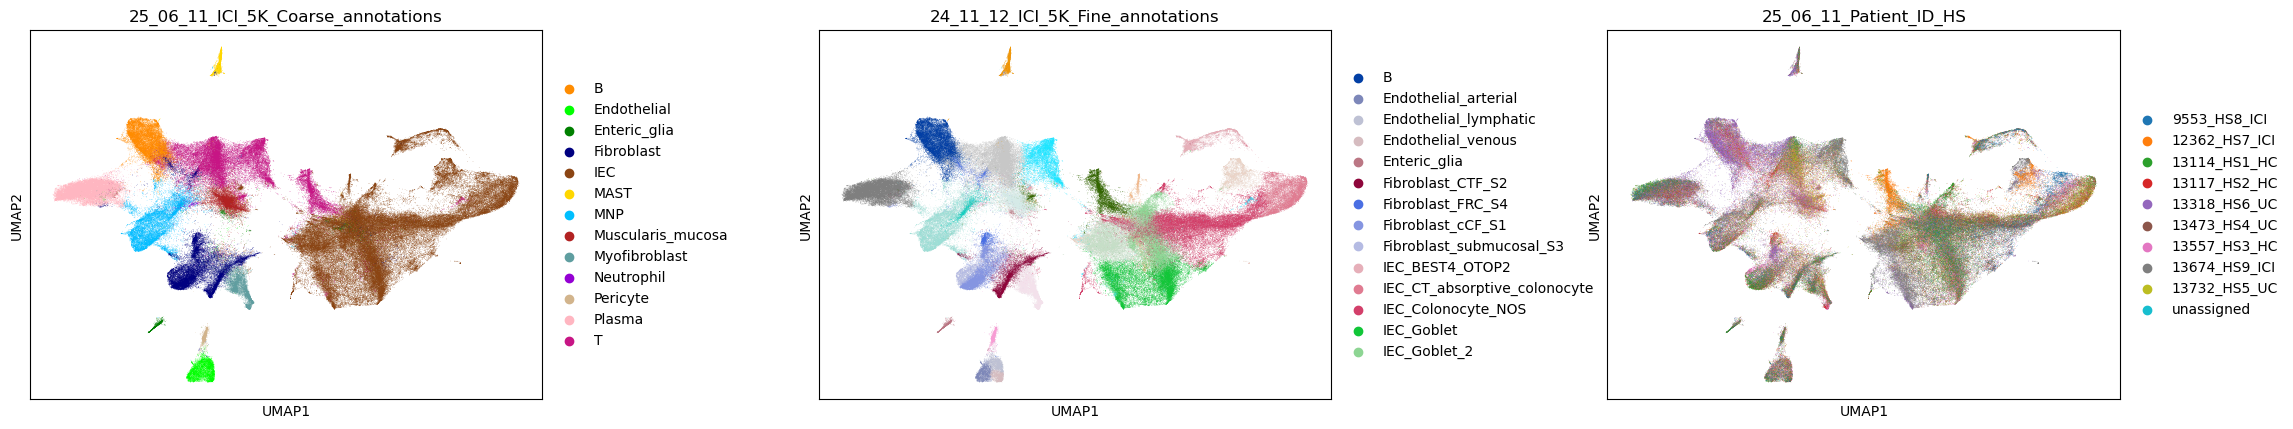

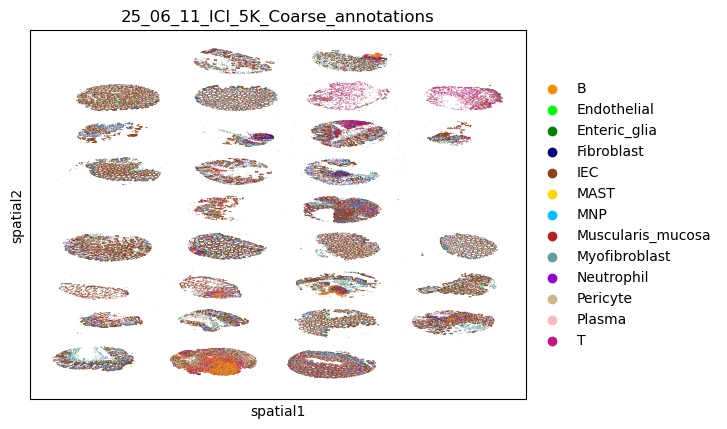

In [7]:
# 1. Plot on UMAP
# Colored by coarse annotations, fine annotations, and Patient ID
sc.pl.umap(adata, color=[
    '25_06_11_ICI_5K_Coarse_annotations', 
    '24_11_12_ICI_5K_Fine_annotations',
    '25_06_11_Patient_ID_HS'
], wspace=0.4) # wspace adds horizontal space between plots for long legends

# 2. Plot in Spatial Coordinates
# Using sc.pl.embedding is often the safest way to plot spatial coordinates 
# when background tissue images aren't loaded into adata.uns
sc.pl.embedding(adata, basis='spatial', color='25_06_11_ICI_5K_Coarse_annotations')

In [8]:
# Create a dictionary to hold the split AnnData objects
adata_by_patient = {}

# Get a list of unique patient IDs
patient_ids = adata.obs['25_06_11_Patient_ID_HS'].unique()

for pid in patient_ids:
    # Slice the original anndata and use .copy() to ensure it's a completely independent object in memory
    adata_by_patient[pid] = adata[adata.obs['25_06_11_Patient_ID_HS'] == pid].copy()
    print(f"Created subset for {pid}: {adata_by_patient[pid].n_obs} cells")

# You can now access individual samples like this:
# adata_patient1 = adata_by_patient['Patient_1_Name']

Created subset for 13557_HS3_HC: 32641 cells
Created subset for 12362_HS7_ICI: 16513 cells
Created subset for 13732_HS5_UC: 27076 cells
Created subset for 13117_HS2_HC: 26109 cells
Created subset for 13473_HS4_UC: 36118 cells
Created subset for 13114_HS1_HC: 36350 cells
Created subset for unassigned: 127 cells
Created subset for 13674_HS9_ICI: 34444 cells
Created subset for 9553_HS8_ICI: 17466 cells
Created subset for 13318_HS6_UC: 33767 cells


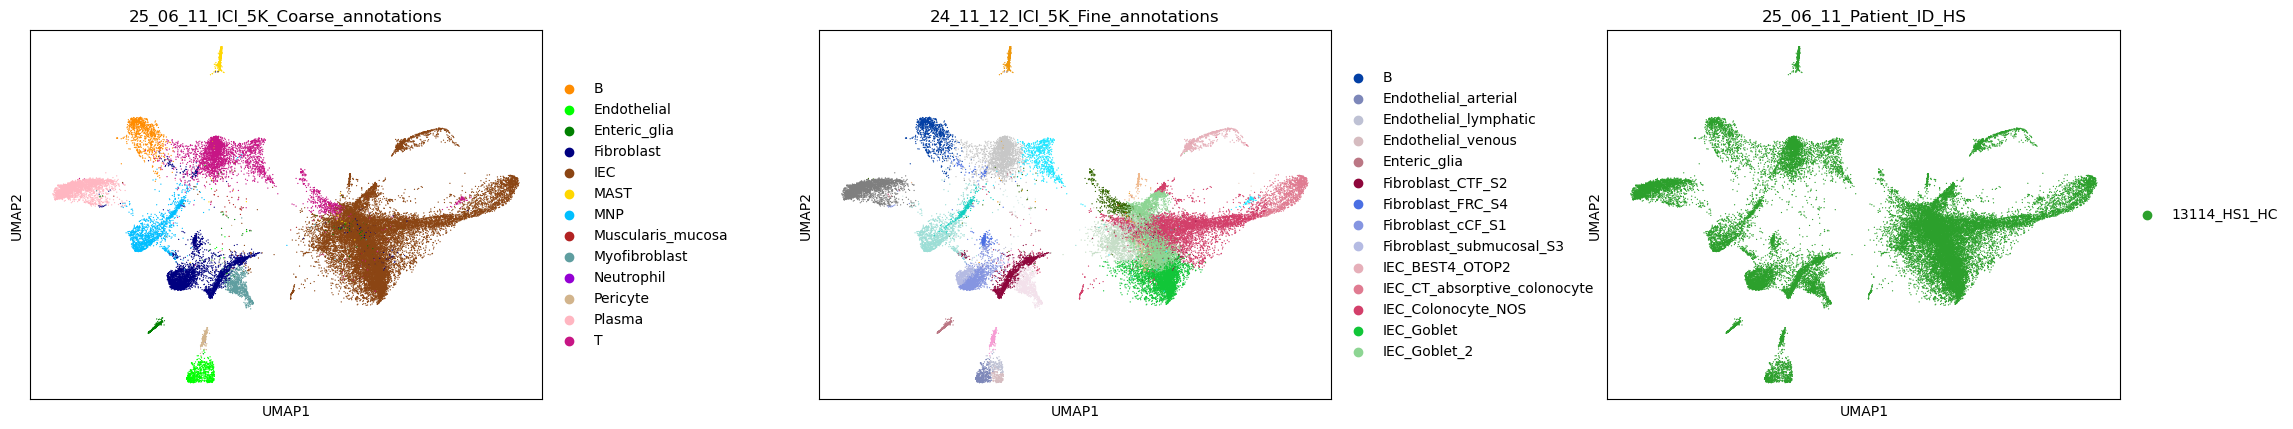

In [9]:
sc.pl.umap(adata_by_patient['13114_HS1_HC'], color=[
    '25_06_11_ICI_5K_Coarse_annotations', 
    '24_11_12_ICI_5K_Fine_annotations',
    '25_06_11_Patient_ID_HS'
], wspace=0.4) # wspace adds horizontal space between plots for long legends

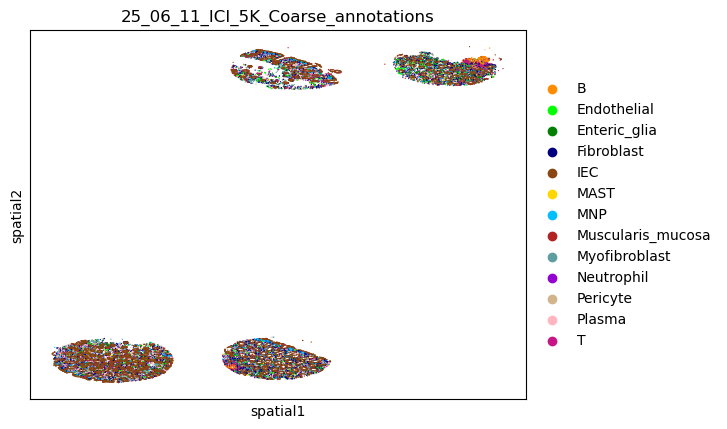

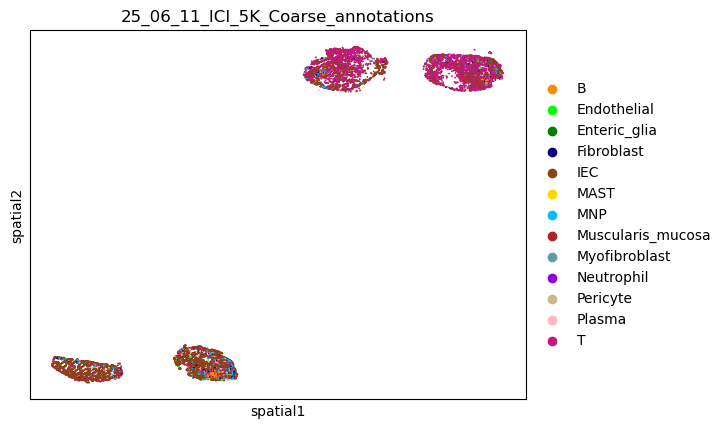

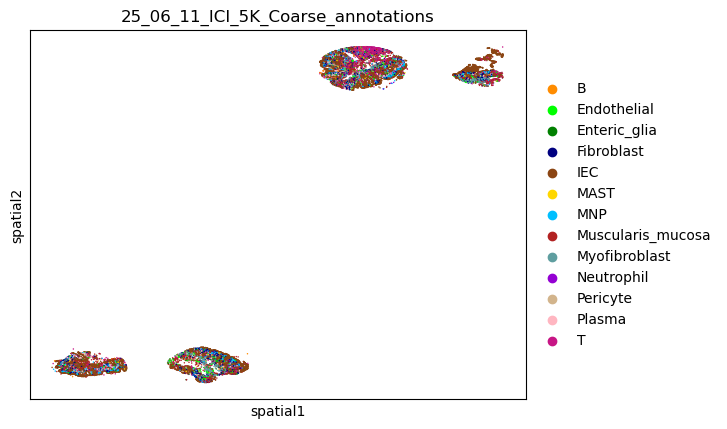

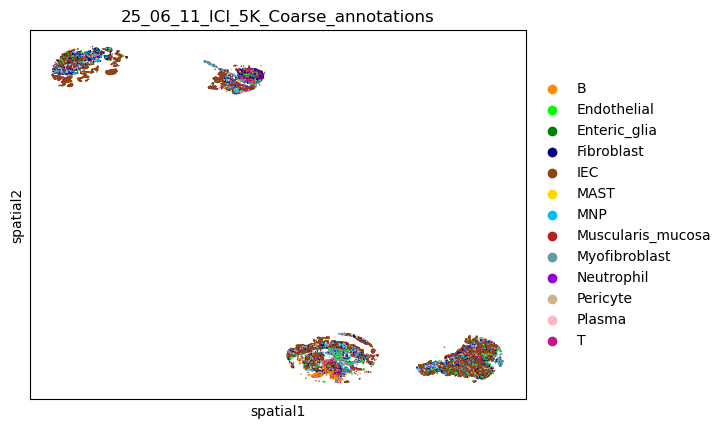

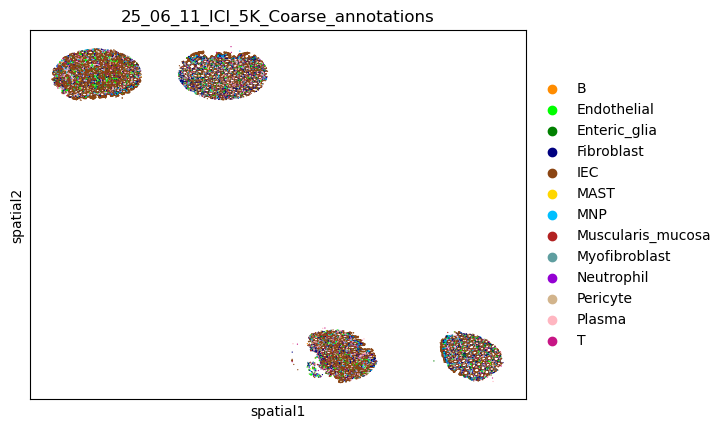

In [10]:
sc.pl.embedding(adata_by_patient['13114_HS1_HC'], basis='spatial', color='25_06_11_ICI_5K_Coarse_annotations')
sc.pl.embedding(adata_by_patient['12362_HS7_ICI'], basis='spatial', color='25_06_11_ICI_5K_Coarse_annotations')
sc.pl.embedding(adata_by_patient['13732_HS5_UC'], basis='spatial', color='25_06_11_ICI_5K_Coarse_annotations')
sc.pl.embedding(adata_by_patient['13117_HS2_HC'], basis='spatial', color='25_06_11_ICI_5K_Coarse_annotations')
sc.pl.embedding(adata_by_patient['13473_HS4_UC'], basis='spatial', color='25_06_11_ICI_5K_Coarse_annotations')

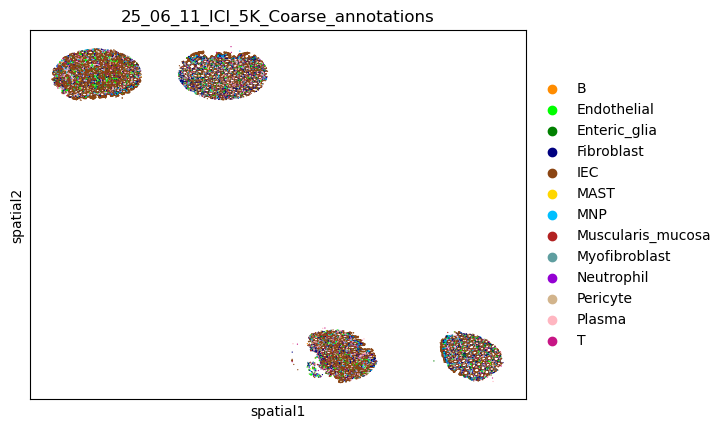

In [11]:
sc.pl.embedding(adata_by_patient['13473_HS4_UC'], basis='spatial', color='25_06_11_ICI_5K_Coarse_annotations')

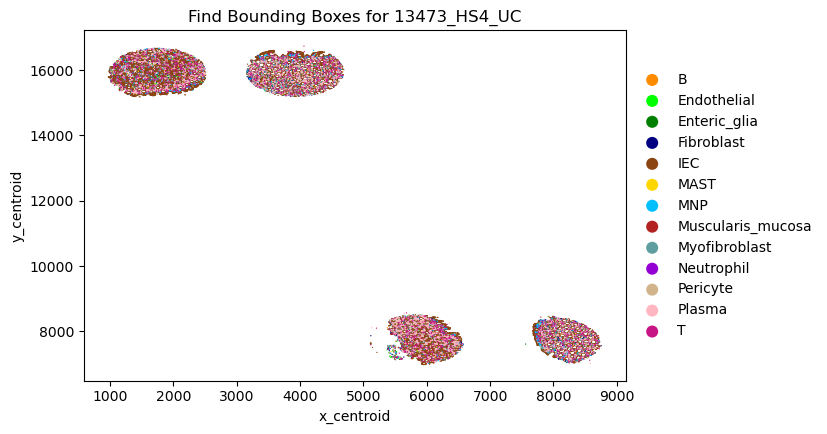

In [12]:
# Define your patient subset
adata_patient = adata_by_patient['13473_HS4_UC']

# Plot using scatter to force X and Y coordinate axes to display
sc.pl.scatter(
    adata_patient, 
    x='x_centroid', 
    y='y_centroid', 
    color='25_06_11_ICI_5K_Coarse_annotations',
    title="Find Bounding Boxes for 13473_HS4_UC"
)

Isolated Slice_1: 12142 cells
Isolated Slice_2: 9930 cells
Isolated Slice_3: 8316 cells
Isolated Slice_4: 5730 cells


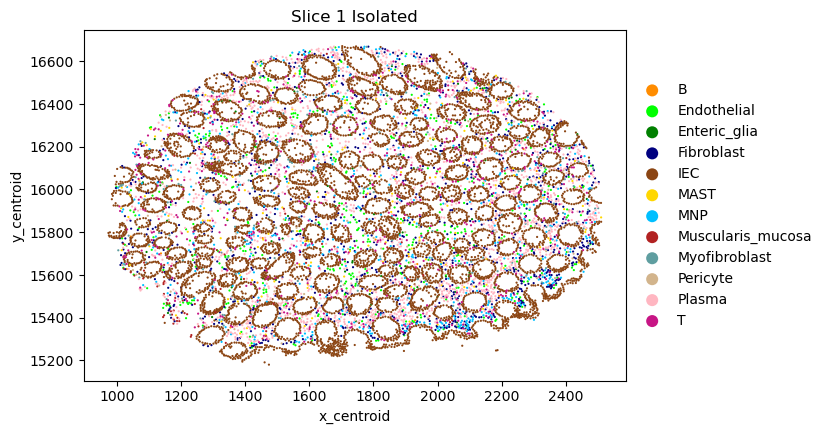

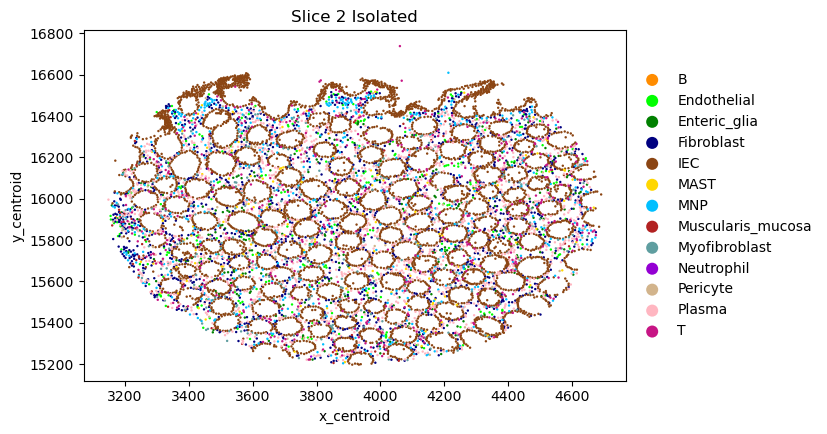

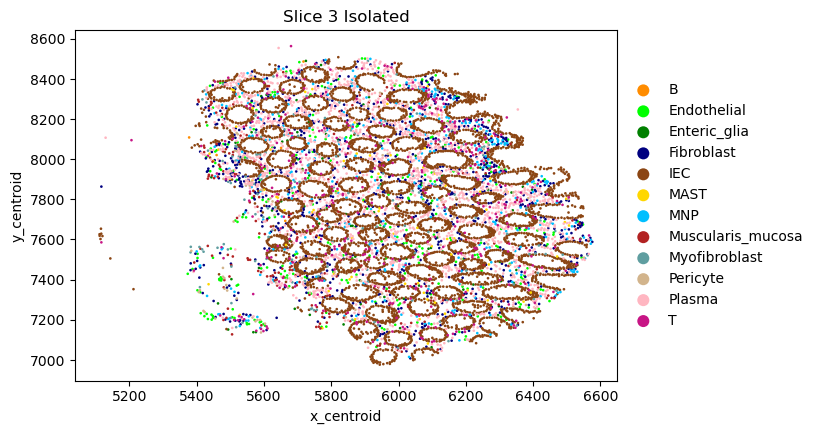

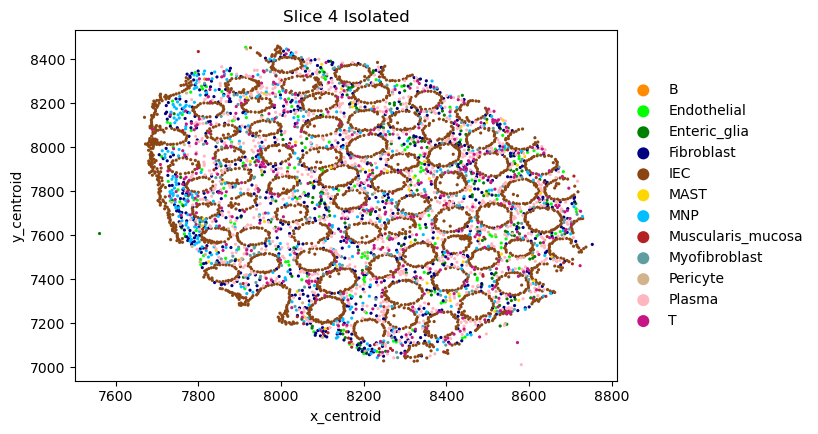

In [13]:
# 1. Define your bounding boxes based on what you saw in the scatter plot
# Format: 'Slice_Name': (x_min, x_max, y_min, y_max)
bounding_boxes = {
    'Slice_1': (0, 3000, 12000, 20000),       # Replace these numbers with your visual estimates
    'Slice_2': (3000, 6000, 12000, 20000), 
    'Slice_3': (4000, 7000, 0, 10000),
    'Slice_4': (7000, 10000, 0, 10000)
}

# 2. Create a dictionary to hold the isolated slices
adata_slices = {}

# 3. Loop through and crop
for slice_name, (xmin, xmax, ymin, ymax) in bounding_boxes.items():
    
    # Create a boolean mask for cells that fall within this specific bounding box
    mask = (
        (adata_patient.obs['x_centroid'] >= xmin) & 
        (adata_patient.obs['x_centroid'] <= xmax) & 
        (adata_patient.obs['y_centroid'] >= ymin) & 
        (adata_patient.obs['y_centroid'] <= ymax)
    )
    
    # Subset the object and use .copy() to keep it independent
    adata_slices[slice_name] = adata_patient[mask].copy()
    
    print(f"Isolated {slice_name}: {adata_slices[slice_name].n_obs} cells")

# 4. Verify your crop worked by plotting one of the new isolated slices
sc.pl.scatter(
    adata_slices['Slice_1'], 
    x='x_centroid', 
    y='y_centroid', 
    color='25_06_11_ICI_5K_Coarse_annotations',
    title="Slice 1 Isolated"
)
# 4. Verify your crop worked by plotting one of the new isolated slices
sc.pl.scatter(
    adata_slices['Slice_2'], 
    x='x_centroid', 
    y='y_centroid', 
    color='25_06_11_ICI_5K_Coarse_annotations',
    title="Slice 2 Isolated"
)
# 4. Verify your crop worked by plotting one of the new isolated slices
sc.pl.scatter(
    adata_slices['Slice_3'], 
    x='x_centroid', 
    y='y_centroid', 
    color='25_06_11_ICI_5K_Coarse_annotations',
    title="Slice 3 Isolated"
)
# 4. Verify your crop worked by plotting one of the new isolated slices
sc.pl.scatter(
    adata_slices['Slice_4'], 
    x='x_centroid', 
    y='y_centroid', 
    color='25_06_11_ICI_5K_Coarse_annotations',
    title="Slice 4 Isolated"
)

In [14]:
import os

patient_name = '13473_HS4_UC'

for slice_name, adata_slice in adata_slices.items():
    ADATA_PATH = f"{DATA_DIR}/Alexi_UC_Spliced/{patient_name}-{slice_name}/adata.h5ad"
    os.makedirs(os.path.dirname(ADATA_PATH), exist_ok=True)
    adata_slice.write_h5ad(ADATA_PATH)
    print(f"Saved {slice_name} to: {ADATA_PATH}")

Saved Slice_1 to: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_1/adata.h5ad
Saved Slice_2 to: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_2/adata.h5ad
Saved Slice_3 to: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_3/adata.h5ad
Saved Slice_4 to: /global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_4/adata.h5ad
